In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
bios_new = pd.read_parquet("bios_new.parquet")
bios_new.head()

,ID_Atleta,Atleta,Fecha_Nacimiento,Ciudad_Nacimiento,Region_Nacimiento,Pais_Nacimiento,NOC,Estatura_Cm,Peso_Kg,Fecha_Fallecimiento
0,1,Jean-Francois Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaT
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrenees-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [70]:
bios_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID_Atleta            145500 non-null  int64         
 1   Atleta               145500 non-null  str           
 2   Fecha_Nacimiento     143693 non-null  datetime64[us]
 3   Ciudad_Nacimiento    145500 non-null  str           
 4   Region_Nacimiento    145500 non-null  str           
 5   Pais_Nacimiento      145500 non-null  str           
 6   NOC                  145500 non-null  str           
 7   Estatura_Cm          106651 non-null  float64       
 8   Peso_Kg              102070 non-null  float64       
 9   Fecha_Fallecimiento  33940 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(1), str(5)
memory usage: 17.3 MB


In [71]:
bios_new.isna().sum()

ID_Atleta                   0
Atleta                      0
Fecha_Nacimiento         1807
Ciudad_Nacimiento           0
Region_Nacimiento           0
Pais_Nacimiento             0
NOC                         0
Estatura_Cm             38849
Peso_Kg                 43430
Fecha_Fallecimiento    111560
dtype: int64

SUBCONJUNTO NUEVOS (Ya que la base es de 145499 en total y la variable fecha_fallecimiento asciende a mas de 111,000 dato nulo reales) se creara subconjuntos para tratar con los nulos reales

In [72]:
df_geo = bios_new.dropna(subset=["Pais_Nacimiento","Region_Nacimiento","Ciudad_Nacimiento","NOC"]).copy()
df_fisico = bios_new.dropna(subset=["Estatura_Cm","Peso_Kg"]).copy()
df_tiempo = bios_new.dropna(subset=["Fecha_Nacimiento"]).copy()
df_fallecidos = bios_new.dropna(subset=["Fecha_Fallecimiento"]).copy()

Analisis Descriptivo

In [73]:
bios_new["Pais_Nacimiento"].value_counts().head(11)

Pais_Nacimiento
Unknown    34592
USA         9641
GER         6891
GBR         5792
FRA         5143
ITA         4709
CAN         4616
RUS         4276
AUS         3009
POL         2942
SWE         2853
Name: count, dtype: int64

In [74]:
bios_new["Region_Nacimiento"].value_counts().head(10)

Region_Nacimiento
Unknown                34592
England                 4824
Ontario                 1710
California              1634
Budapest                1447
New South Wales         1120
Bayern                  1095
Nordrhein-Westfalen     1071
Quebec                   991
New York                 990
Name: count, dtype: int64

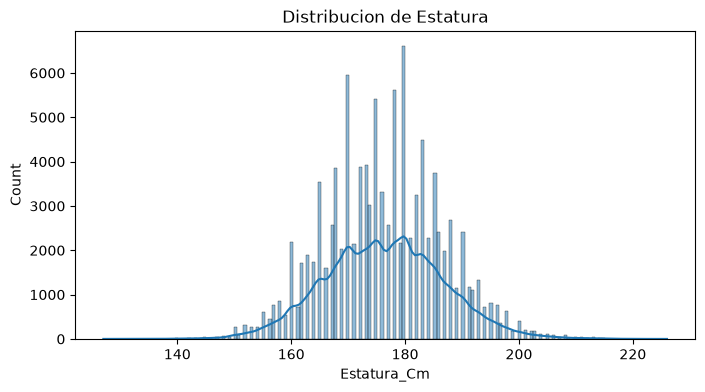

In [75]:
plt.figure(figsize=(8,4))
sns.histplot(data=bios_new, x="Estatura_Cm", kde=True)
plt.title("Distribucion de Estatura")
plt.show()

La “Distribución de Estatura” presenta un histograma con curva de densidad. La forma es similar a una campana, centrada alrededor de los 175 cm, lo que indica que la estatura se distribuye de manera aproximadamente normal: pocas personas muy bajas o muy altas, y una gran concentración cerca de la media. Esto confirma que la mayoría de los atletas tiene una estatura cercana a ese valor.

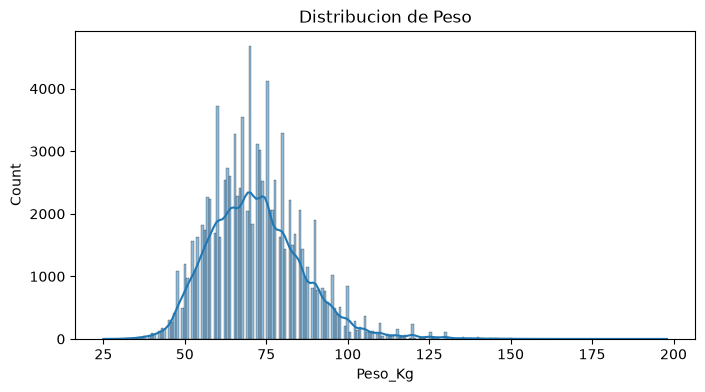

In [76]:
plt.figure(figsize=(8,4))
sns.histplot(data=bios_new, x="Peso_Kg", kde=True)
plt.title("Distribucion de Peso")
plt.show()

La “Distribución de Peso” también muestra una forma de campana, pero ligeramente sesgada hacia la derecha, centrada cerca de los 70–75 kg. Hay más casos con pesos algo superiores que inferiores a la media, lo que sugiere que la distribución de peso es menos simétrica que la de estatura. Aun así, la mayor concentración sigue estando en un rango relativamente saludable para deportistas.

Analisis Geografico

In [77]:
mapping = {
    "USA": "Estados Unidos",
    "GER": "Alemania",
    "GBR": "Reino Unido",
    "FRA": "Francia",
    "ITA": "Italia",
    "CAN": "Canada",
    "RUS": "Rusia",
    "AUS": "Australia",
    "POL": "Polonia",
    "SWE": "Suecia"
}

top_country = (
    df_geo["Pais_Nacimiento"]
    .value_counts()
    .head(11)
    .reset_index()
)
top_country.columns = ["Pais_codigo", "Cantidad"]
top_country["Pais"] = top_country["Pais_codigo"].map(mapping)

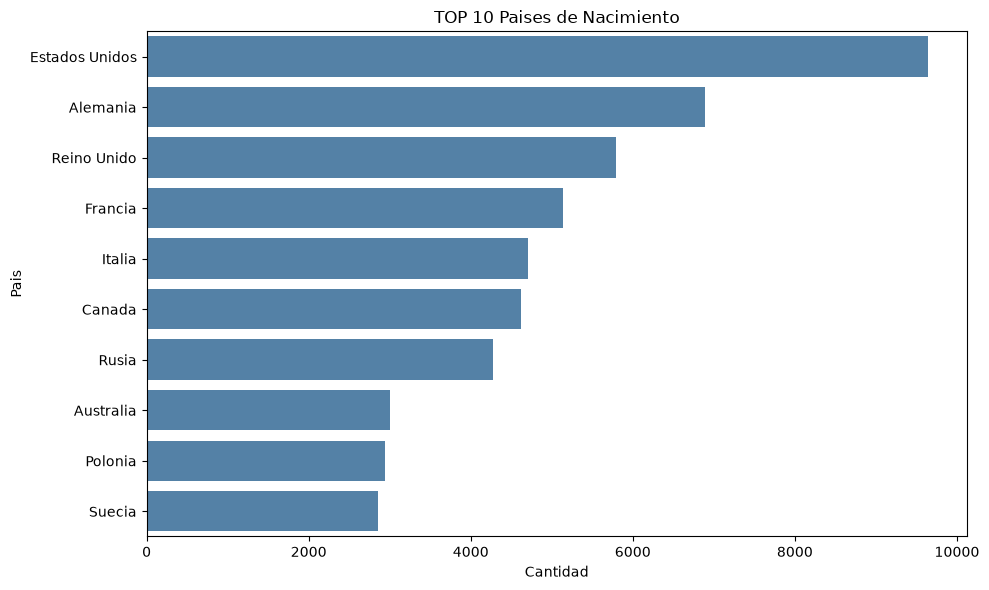

In [92]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_country, x="Cantidad", y="Pais", color="steelblue")
plt.title("TOP 10 Paises de Nacimiento")
plt.xlabel("Cantidad")
plt.ylabel("Pais")
#plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

El gráfico de “TOP 10 Países de Nacimiento” destaca los países con mayor cantidad de atletas registrados. Estados Unidos encabeza claramente la lista, seguido por Alemania, Reino Unido y Francia. Países como Italia, Canadá y Rusia también tienen presencia importante, mientras que Australia, Polonia y Suecia cierran el top 10. Esto sugiere que la base tiene una fuerte representación de países con tradición deportiva y buena infraestructura para participar en eventos internacionales.

Analisis Fisico

In [79]:
df_fisico["IMC"] = df_fisico["Peso_Kg"] / (df_fisico["Estatura_Cm"]/100)**2
df_fisico[["Estatura_Cm","Peso_Kg","IMC"]].describe()

,Estatura_Cm,Peso_Kg,IMC
count,102070.000000,102070.000000,102070.000000
mean,176.334780,71.890996,22.933276
std,10.379696,14.465540,3.001614
min,127.000000,25.000000,10.503834
25%,170.000000,62.000000,21.007668
50%,176.000000,70.000000,22.675737
75%,183.000000,80.000000,24.419279
max,226.000000,198.000000,56.495351


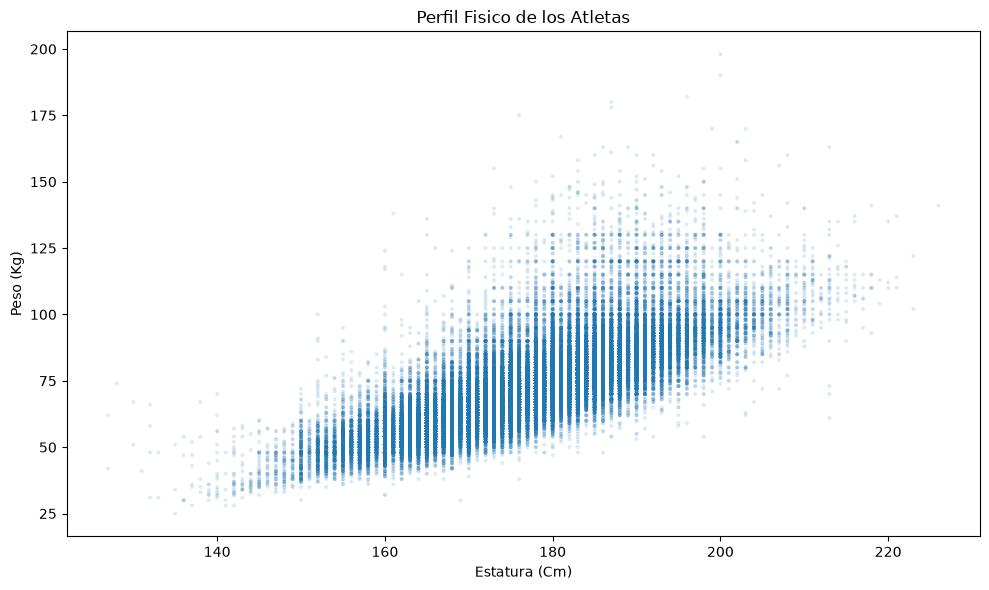

In [93]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_fisico, x="Estatura_Cm", y="Peso_Kg", alpha=0.15, s=8, edgecolors="none")
plt.title("Perfil Fisico de los Atletas")
plt.xlabel("Estatura (Cm)")
plt.ylabel("Peso (Kg)")
plt.tight_layout()
plt.show()

El gráfico de “Perfil físico de los atletas” muestra la relación entre estatura y peso. Se observa una correlación positiva: a medida que aumenta la estatura, también tiende a aumentar el peso. La mayor parte de los atletas se concentra aproximadamente entre 170–180 cm de estatura y 60–80 kg de peso, lo que define el rango físico más típico en la base. Los puntos más alejados representan casos menos frecuentes de atletas muy bajos o muy altos, y con pesos extremos.

Analisis Temporal

In [81]:
df_tiempo["Año_Nacimiento"] = df_tiempo["Fecha_Nacimiento"].dt.year
df_tiempo["Nacido_Decada"] = (df_tiempo["Año_Nacimiento"] // 10)*10

df_tiempo["Año_Nacimiento"].describe()

count    143693.000000
mean       1957.064464
std          31.469023
min        1828.000000
25%        1939.000000
50%        1964.000000
75%        1982.000000
max        2009.000000
Name: Año_Nacimiento, dtype: float64

In [82]:

df_tiempo["Nacido_Decada"].value_counts().sort_index()

Nacido_Decada
1820        1
1830        7
1840       35
1850      154
1860      485
1870     1636
1880     3686
1890     3785
1900     5515
1910     5095
1920     6705
1930     9756
1940    12390
1950    13772
1960    19215
1970    21074
1980    21089
1990    15928
2000     3365
Name: count, dtype: int64

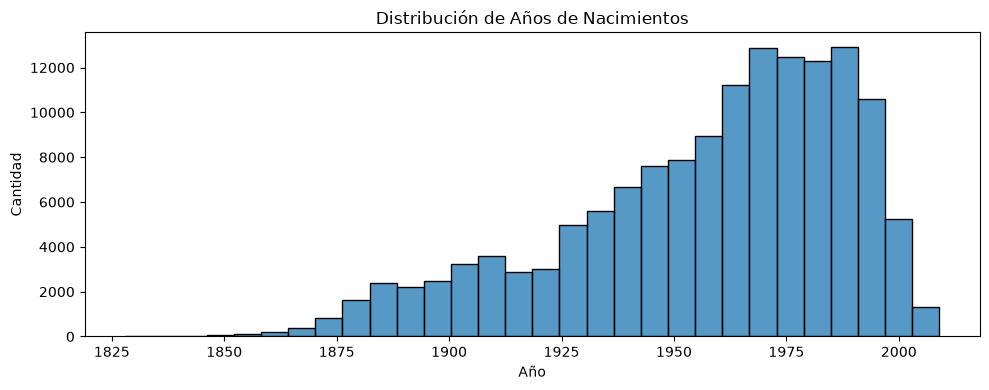

In [83]:
plt.figure(figsize=(10,4))
sns.histplot(data=df_tiempo, x="Año_Nacimiento", bins=30)
plt.title("Distribución de Años de Nacimientos")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

La “Distribución de Años de Nacimientos” muestra cómo se concentra la fecha de nacimiento de los atletas a lo largo del tiempo. Se observa un crecimiento progresivo desde finales del siglo XIX hasta un máximo entre 1960 y finales de los 70, seguido de una ligera caída hacia los años 90 y 2000. Esto refleja tanto la expansión del deporte moderno como la cobertura de la base de datos: hay muchos más registros de atletas nacidos en la segunda mitad del siglo XX.

In [84]:
bios_new["Estado_Fallecimiento"] = np.where(
    bios_new["Fecha_Fallecimiento"].isna(),
    "Sin Fecha de Fallecimiento",
    "Con Fecha de Fallecimiento"
)
bios_new["Estado_Fallecimiento"].value_counts()

Estado_Fallecimiento
Sin Fecha de Fallecimiento    111560
Con Fecha de Fallecimiento     33940
Name: count, dtype: int64

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6832\2430604598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bios_new, x="Estado_Fallecimiento", palette="Set2")


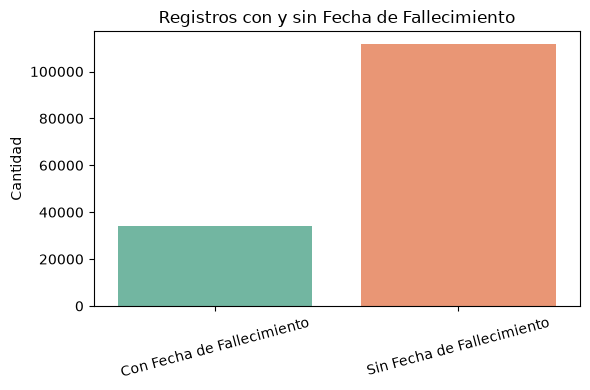

In [85]:
plt.figure(figsize=(6,4))
sns.countplot(data=bios_new, x="Estado_Fallecimiento", palette="Set2")
plt.title("Registros con y sin Fecha de Fallecimiento")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

El gráfico de “Registros con y sin fecha de fallecimiento” compara la cantidad de atletas con fecha registrada frente a los que no la tienen. La gran mayoría de registros aparece en la categoría “Sin fecha de fallecimiento”, lo que indica que este campo está muy incompleto o que muchos atletas siguen vivos. Por eso, cualquier análisis profundo sobre edad al fallecer o distribución temporal de fallecimientos debe tomarse con cautela.